In [ ]:
#Exercise 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 3, 5, 4, 6], dtype=float)

x_bar = x.mean()
y_bar = y.mean()

print(f"x-bar = {x_bar:.1f}")
print(f"y-bar = {y_bar:.1f}")

x-bar = 3.0
y-bar = 4.0


In [3]:
centered = pd.DataFrame(
    {
        "x": x,
        "y": y,
        "x - x-bar": x - x_bar,
        "y - y-bar": y - y_bar,
    }
)

centered["centered product"] = centered["x - x-bar"] * centered["y - y-bar"]
centered["squared x deviation"] = centered["x - x-bar"] ** 2
centered

,x,y,x - x-bar,y - y-bar,centered product,squared x deviation
0,1.0,2.0,-2.0,-2.0,4.0,4.0
1,2.0,3.0,-1.0,-1.0,1.0,1.0
2,3.0,5.0,0.0,1.0,0.0,0.0
3,4.0,4.0,1.0,0.0,0.0,1.0
4,5.0,6.0,2.0,2.0,4.0,4.0


In [4]:
numerator = centered["centered product"].sum()
denominator = centered["squared x deviation"].sum()

beta_1 = numerator / denominator
beta_0 = y_bar - beta_1 * x_bar

print(f"sum of centered products = {numerator:.1f}")
print(f"sum of squared x deviations = {denominator:.1f}")
print(f"beta_1 (slope) = {beta_1:.1f}")
print(f"beta_0 (intercept) = {beta_0:.1f}")
print(f"Fitted line: y-hat = {beta_0:.1f} + {beta_1:.1f}x")

sum of centered products = 9.0
sum of squared x deviations = 10.0
beta_1 (slope) = 0.9
beta_0 (intercept) = 1.3
Fitted line: y-hat = 1.3 + 0.9x


In [5]:
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)

print(f"scikit-learn Intercept (beta_0): {model.intercept_:.1f}")
print(f"scikit-learn Slope (beta_1): {model.coef_[0]:.1f}")

scikit-learn Intercept (beta_0): 1.3
scikit-learn Slope (beta_1): 0.9


In [ ]:
#Exercise 3
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
np.random.seed(42)
N = 50
X = np.random.uniform(0, 10, N).reshape(-1, 1)
true_beta0, true_beta1 = 2.0, 1.5
y = true_beta0 + true_beta1 * X.ravel() + np.random.normal(0, 0.5, N)
model = LinearRegression().fit(X, y)

In [21]:
print(f"Intercept: {model.intercept_:.3f} (true: {true_beta0})")
print(f"Slope: {model.coef_[0]:.3f} (true: {true_beta1})")
print(f"R²: {r2_score(y, model.predict(X)):.3f}")

Intercept: 2.048 (true: 2.0)
Slope: 1.489 (true: 1.5)
R²: 0.989


In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Given dataset points: (1,2), (2,3), (3,5), (4,4), (5,6)
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 3, 5, 4, 6])

# Fit Ordinary Least Squares model
model = LinearRegression().fit(X, y)

# Output results
print(f"Intercept (beta_0): {model.intercept_:.3f}")
print(f"Slope (beta_1):     {model.coef_[0]:.3f}")

Intercept (beta_0): 1.300
Slope (beta_1):     0.900


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [49]:
seed = 42
n = 10
true_intercept = 2.0
true_slope = 1.5
noise_std = 0.5

rng = np.random.default_rng(seed)

In [50]:
X = rng.uniform(0, 10, n).reshape(-1, 1)
y = true_intercept + true_slope * X.ravel() + rng.normal(0, noise_std, n)

In [51]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Fitted intercept: {model.intercept_:.3f}")
print(f"Fitted slope:     {model.coef_[0]:.3f}")
print(f"R-squared:         {r2_score(y, y_pred):.3f}")

Fitted intercept: 2.464
Fitted slope:     1.445
R-squared:         0.995


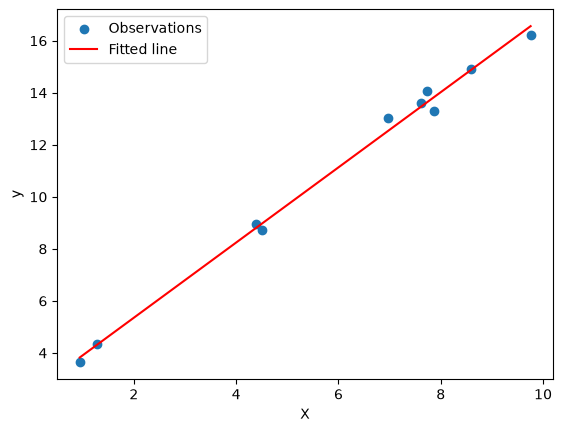

In [52]:
X_sorted = np.sort(X, axis=0)
y_sorted_pred = model.predict(X_sorted)

plt.scatter(X, y, label="Observations")
plt.plot(X_sorted, y_sorted_pred, color="red", label="Fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()